In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
file_path = r"C:\Users\shash\OneDrive - purdue.edu\Pulse Rate Wearable Sensor\heartrate.bmp.data" 

In [11]:
with open(file_path, "r") as f:
    lines = f.readlines()
for i, line in enumerate(lines):
    if "***End_of_Header***" in line:
        header_end = i
        break
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    skiprows=header_end + 1
)

print(df.head())

df.to_csv("heartrate_bmp_data.csv", index=False)

    Time       Current  Filtered  Current.1
0  0.001  6.382060e-10       NaN        NaN
1  0.002  6.385281e-10       NaN        NaN
2  0.003  6.382060e-10       NaN        NaN
3  0.004  6.378839e-10       NaN        NaN
4  0.005  6.378839e-10       NaN        NaN


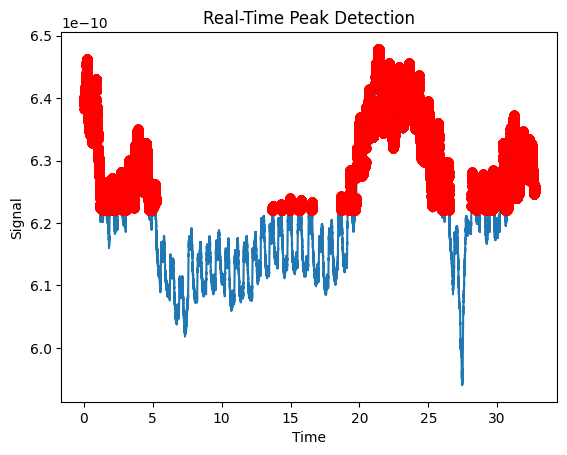

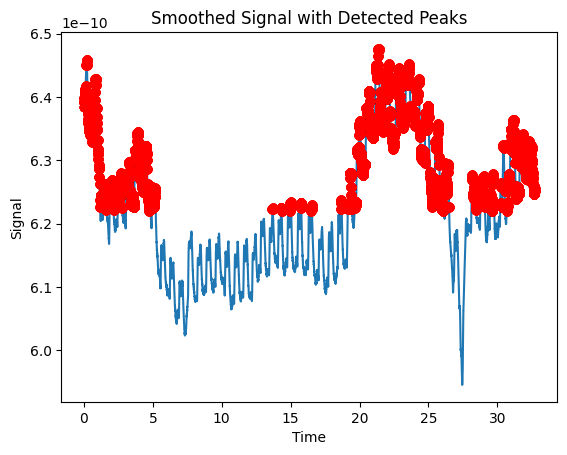

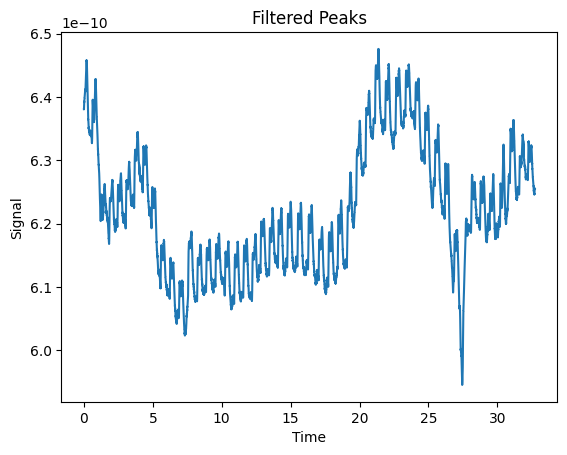

In [105]:
from scipy.signal import find_peaks

def real_time_peak_detection(stream, window_size, threshold):
    buf = []
    peak_idx = []
    for idx, sample in enumerate(stream):
        buf.append(sample)
        if len(buf) >= window_size:
            window_arr = np.array(buf[-window_size:])
            local, _ = find_peaks(window_arr, height=threshold)
            for lp in local:
                global_idx = idx - window_size + 1 + lp
                if global_idx >= 0:
                    peak_idx.append(global_idx)
    return peak_idx

def smooth_signal(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

def filter_false_peaks(peaks, data, min_distance, min_prominence):
    filtered = []
    for p in peaks:
        left = max(p - min_distance, 0)
        right = min(p + min_distance, len(data))
        neighborhood = data[left:right]
        if len(neighborhood) == 0:
            continue
        if data[p] > neighborhood.max() and data[p] - neighborhood.min() > min_prominence:
            filtered.append(p)
    return filtered

# stream the real-time signal from the dataframe
signal_series = df["Current"].values
time_series = df["Time"].values

WINDOW_SIZE = 50
threshold = signal_series.mean()  # adjust as needed for your data scale
peaks = real_time_peak_detection(signal_series, WINDOW_SIZE, threshold)

plt.plot(time_series, signal_series)
plt.plot(time_series[peaks], signal_series[peaks], 'ro')
plt.title('Real-Time Peak Detection')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.show()

smoothed_signal = smooth_signal(signal_series, window_size=10)
peaks_smoothed = real_time_peak_detection(smoothed_signal, WINDOW_SIZE, threshold)

plt.plot(time_series[:len(smoothed_signal)], smoothed_signal)
plt.plot(time_series[peaks_smoothed], smoothed_signal[peaks_smoothed], 'ro')
plt.title('Smoothed Signal with Detected Peaks')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.show()

min_distance = 10
min_prominence = 0.2
filtered_peaks = filter_false_peaks(peaks_smoothed, smoothed_signal, min_distance, min_prominence)

plt.plot(time_series[:len(smoothed_signal)], smoothed_signal)
plt.plot(time_series[filtered_peaks], smoothed_signal[filtered_peaks], 'ro')
plt.title('Filtered Peaks')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.show()

In [92]:
MAX = 3000
i = 0
WINDOW_SIZE = 1000
SMOOTH_MS = 10
from scipy.signal import savgol_filter

window_signal = []
window_time = []
recorded = []
all_peaks = []

def real_time_peak_detection(data, window_size, threshold):
    peaks = []
    peak_indices, _ = find_peaks(data, height=threshold)
    peaks.extend(peak_indices)
    return peaks

def filter_false_peaks(peaks, data, min_distance, min_prominence):
    filtered_peaks = []
    for peak in peaks:
        if all(data[peak] > data[peak - min_distance:peak + min_distance]) and data[peak] - min(data[peak - min_distance:peak + min_distance]) > min_prominence:
            filtered_peaks.append(peak)
    return filtered_peaks

for (time, current) in zip(df["Time"], df["Current"]):
    recorded.append(current)
    window_signal.append(current)
    window_time.append(time)
    if len(window_signal) > WINDOW_SIZE:
        window_signal.pop(0)
        window_time.pop(0)
    smooth = np.convolve(window_signal, np.ones(WINDOW_SIZE), mode='valid')
    peaks = real_time_peak_detection(smooth, WINDOW_SIZE, threshold=np.mean(smooth))
    # Filter false peaks
    min_distance = 10
    min_prominence = 0.2
    filtered_peaks = filter_false_peaks(peaks, smooth, min_distance, min_prominence)
    i += 1
    if i >= MAX:
        break
    all_peaks.extend([(window_time[peak], smooth[peak]) for peak in filtered_peaks])



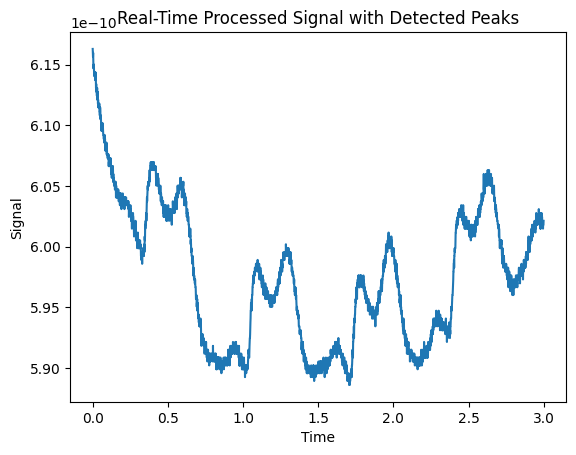

In [93]:
plt.plot(df["Time"][:MAX], df["Current"][:MAX], label='Original Signal')
plt.scatter( [tp[0] for tp in all_peaks if tp[0] <= df["Time"][MAX-1]],
            [tp[1] for tp in all_peaks if tp[0] <= df["Time"][MAX-1]],
            color='red', label='Detected Peaks')
plt.title('Real-Time Processed Signal with Detected Peaks')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.show()

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

class RealtimePeakDetector:
    def __init__(self, fs, smooth_ms=10, savgol_window=33, savgol_poly=3, 
                 prominence_factor=0.02, min_peak_distance_s=0.15):
        """
        Real-time peak detector matching your original implementation
        
        Args:
            fs: Sampling frequency (Hz)
            smooth_ms: Smoothing window in milliseconds
            savgol_window: Savitzky-Golay filter window length (must be odd)
            savgol_poly: Savitzky-Golay polynomial order
            prominence_factor: Prominence threshold as factor of signal std
            min_peak_distance_s: Minimum distance between peaks in seconds
        """
        self.fs = fs
        self.smooth_samples = int(smooth_ms * fs / 1000)
        self.savgol_window = savgol_window if savgol_window % 2 == 1 else savgol_window + 1
        self.savgol_poly = savgol_poly
        self.prominence_factor = prominence_factor
        self.min_peak_distance_samples = int(fs * min_peak_distance_s)
        
        # Buffers
        self.smooth_buffer = deque(maxlen=self.smooth_samples)
        self.savgol_buffer = deque(maxlen=self.savgol_window)
        self.signal_buffer = deque(maxlen=200)  # For std calculation
        
        # Output storage
        self.time_data = []
        self.raw_data = []
        self.smooth_data = []
        self.savgol_data = []
        self.final_signal = []
        
        # Peak detection
        self.detected_peaks = []
        self.peak_times = []
        self.peak_values = []
        self.last_peak_idx = -self.min_peak_distance_samples
        
        # Baseline
        self.baseline_value = None
        self.baseline_determined = False
        
        # For Savitzky-Golay we need some history
        self.all_smoothed = []
        
    def process_point(self, time, current):
        """Process a single data point in real-time"""
        idx = len(self.time_data)
        
        # Store raw
        self.time_data.append(time)
        self.raw_data.append(current)
        
        # Step 1: Rolling mean smoothing
        self.smooth_buffer.append(current)
        smoothed = np.mean(self.smooth_buffer)
        self.smooth_data.append(smoothed)
        self.all_smoothed.append(smoothed)
        
        # Step 2: Savitzky-Golay smoothing (needs full window)
        if len(self.all_smoothed) >= self.savgol_window:
            # Apply SavGol to the last window of data
            recent_data = list(self.all_smoothed[-self.savgol_window:])
            
            # Apply savgol filter and take the center point
            from scipy.signal import savgol_filter
            filtered = savgol_filter(recent_data, 
                                    window_length=self.savgol_window, 
                                    polyorder=self.savgol_poly)
            savgol_value = filtered[self.savgol_window // 2]
        else:
            # Not enough data yet, use smoothed value
            savgol_value = smoothed
        
        self.savgol_data.append(savgol_value)
        self.savgol_buffer.append(savgol_value)
        
        # Step 3: Baseline correction
        if not self.baseline_determined and len(self.savgol_data) >= 100:
            # Determine baseline from first N points
            self.baseline_value = float(np.clip(np.min(self.savgol_data), 0, None))
            self.baseline_determined = True
            print(f"Baseline determined: {self.baseline_value:.6e}")
        
        if self.baseline_determined:
            signal_bc = max(0, savgol_value)  # Clamp to >= 0
            final = signal_bc - self.baseline_value
        else:
            final = 0  # No signal until baseline is determined
        
        self.final_signal.append(final)
        self.signal_buffer.append(final)
        
        # Step 4: Peak detection (only after baseline is set)
        if self.baseline_determined and len(self.signal_buffer) >= 50:
            self._detect_peak(idx, time, final)
        
    def _detect_peak(self, idx, time, value):
        """Check if current point is a peak using lookback window"""
        # Need enough data for peak detection
        if len(self.final_signal) < 20:
            return
        
        # Calculate signal std from buffer
        signal_std = np.std(list(self.signal_buffer))
        prominence_threshold = signal_std * self.prominence_factor
        
        # Look back a few points to check if THAT point was a peak
        # This allows us to see both sides of the peak
        lookback = 50  # Check point 50 samples ago
        
        if idx < lookback:
            return
        
        check_idx = idx - lookback
        
        # Check minimum distance from last peak
        if check_idx - self.last_peak_idx < self.min_peak_distance_samples:
            return
        
        # Get neighborhood around the point we're checking
        window_size = 10
        start_idx = max(0, check_idx - window_size)
        end_idx = min(len(self.final_signal), check_idx + window_size + 1)
        
        if end_idx - start_idx < 5:  # Need minimum window
            return
        
        # Get local signal window
        local_signal = self.final_signal[start_idx:end_idx]
        center_pos = check_idx - start_idx
        
        # Check if center is local maximum
        center_value = local_signal[center_pos]
        is_peak = all(center_value >= local_signal[i] for i in range(len(local_signal)) if i != center_pos)
        
        if not is_peak:
            return
        
        # Calculate prominence
        # Find bases on left and right
        left_signal = local_signal[:center_pos]
        right_signal = local_signal[center_pos+1:]
        
        left_base = min(left_signal) if len(left_signal) > 0 else center_value
        right_base = min(right_signal) if len(right_signal) > 0 else center_value
        base = max(left_base, right_base)
        prominence = center_value - base
        
        if prominence >= prominence_threshold and center_value > 0:
            self.detected_peaks.append(check_idx)
            self.peak_times.append(self.time_data[check_idx])
            self.peak_values.append(center_value)
            self.last_peak_idx = check_idx
            print(f"Peak detected at t={self.time_data[check_idx]:.3f}s, value={center_value:.2e}, prominence={prominence:.2e}")
    
    def plot_results(self, window_start=None, window_end=None):
        """Plot the processed signal and detected peaks"""
        if window_start is None:
            window_start = 0
        if window_end is None:
            window_end = len(self.time_data)
        
        time_array = np.array(self.time_data)
        signal_array = np.array(self.final_signal)
        
        plt.figure(figsize=(14, 6))
        
        # Plot signal in window
        plt.plot(time_array[window_start:window_end], 
                signal_array[window_start:window_end], 
                label="Processed pulse signal", linewidth=1.4, color='black')
        
        # Plot peaks in window
        peaks_in_window = [(i, t, v) for i, t, v in 
                          zip(self.detected_peaks, self.peak_times, self.peak_values)
                          if window_start <= i < window_end]
        
        if peaks_in_window:
            peak_indices, peak_t, peak_v = zip(*peaks_in_window)
            plt.plot(peak_t, peak_v, 'ro', label="Peak", markersize=9)
            
            # Annotate peaks
            for t, v in zip(peak_t, peak_v):
                plt.annotate(f"({t:.3f}, {v:.2e})",
                           xy=(t, v),
                           xytext=(6, 6),
                           textcoords="offset points",
                           fontsize=8,
                           color='red')
        
        plt.xlabel("Time (s)")
        plt.ylabel("Signal (A.U.)")
        plt.title(f"Prominent Peaks (Real-time Processing) - {len(self.detected_peaks)} peaks detected")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    def plot_processing_steps(self, window_start=None, window_end=None):
        """Plot all processing steps"""
        if window_start is None:
            window_start = 0
        if window_end is None:
            window_end = len(self.time_data)
        
        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        time_array = np.array(self.time_data)
        
        # Raw signal
        axes[0].plot(time_array[window_start:window_end], 
                    np.array(self.raw_data)[window_start:window_end], 
                    label='Raw Signal', color='blue', alpha=0.6)
        axes[0].set_ylabel('Current')
        axes[0].set_title('Raw Signal')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Smoothed signal
        axes[1].plot(time_array[window_start:window_end], 
                    np.array(self.smooth_data)[window_start:window_end], 
                    label='Rolling Mean', color='green')
        axes[1].set_ylabel('Current')
        axes[1].set_title('Rolling Mean Smoothing')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Savgol smoothed
        axes[2].plot(time_array[window_start:window_end], 
                    np.array(self.savgol_data)[window_start:window_end], 
                    label='Savitzky-Golay', color='orange')
        axes[2].set_ylabel('Current')
        axes[2].set_title('Savitzky-Golay Filtering')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        # Final signal with peaks
        axes[3].plot(time_array[window_start:window_end], 
                    np.array(self.final_signal)[window_start:window_end], 
                    label='Final Signal', color='black')
        
        peaks_in_window = [(i, t, v) for i, t, v in 
                          zip(self.detected_peaks, self.peak_times, self.peak_values)
                          if window_start <= i < window_end]
        if peaks_in_window:
            _, peak_t, peak_v = zip(*peaks_in_window)
            axes[3].plot(peak_t, peak_v, 'ro', label="Peaks", markersize=9)
        
        axes[3].set_ylabel('Signal (A.U.)')
        axes[3].set_xlabel('Time (s)')
        axes[3].set_title('Baseline-Corrected Signal with Peaks')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

Loaded 32736 data points from
Sampling frequency: 1000.00 Hz
Time step: 0.001000 s

Processing data point by point (real-time simulation)...
Baseline determined: 6.380449e-10
Peak detected at t=0.219s, value=7.75e-12, prominence=2.88e-13
Peak detected at t=0.663s, value=1.40e-12, prominence=2.05e-13
Peak detected at t=0.869s, value=4.79e-12, prominence=2.34e-13
Processed 1000/32736 points
Processed 2000/32736 points
Processed 3000/32736 points
Processed 4000/32736 points
Processed 5000/32736 points
Processed 6000/32736 points
Processed 7000/32736 points
Processed 8000/32736 points
Processed 9000/32736 points
Processed 10000/32736 points

Processing complete!
Total peaks detected: 3


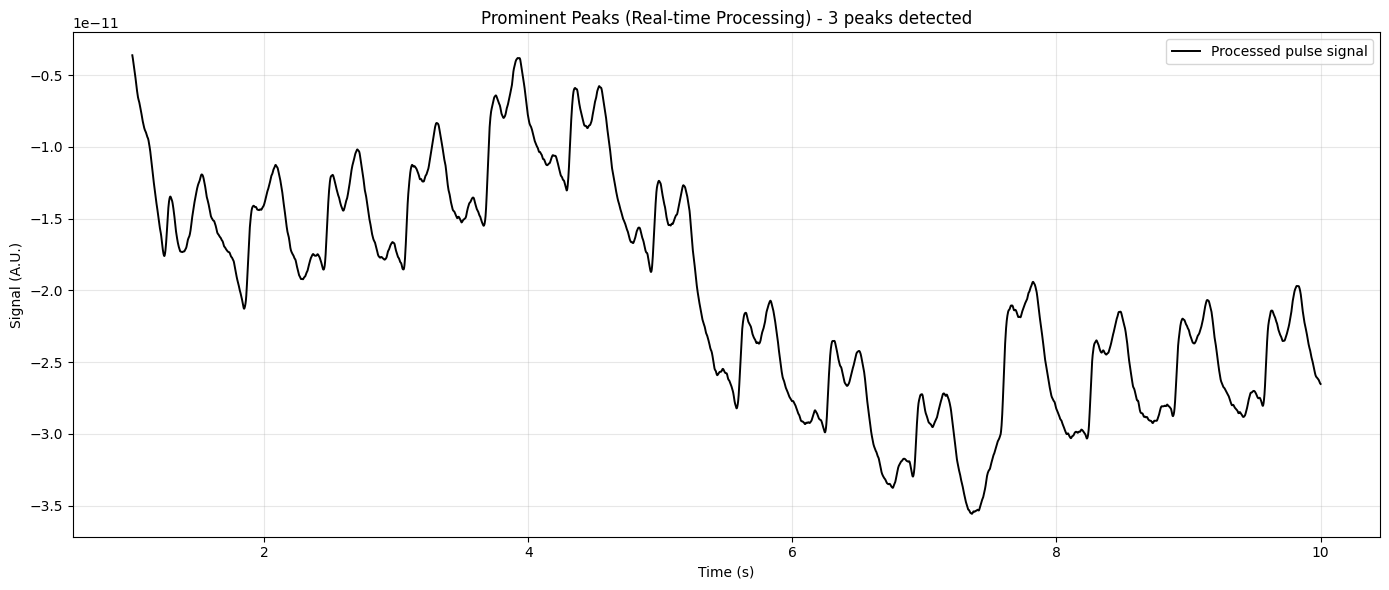

In [106]:


# ===================== MAIN EXECUTION =====================
if __name__ == "__main__":
    # Load CSV file
    
    
    try:
        print(f"Loaded {len(df)} data points from")
        
        # Extract data
        time = df["Time"].values
        current = df["Current"].values
        
        # Calculate sampling frequency
        dt = np.mean(np.diff(time))
        fs = 1 / dt
        print(f"Sampling frequency: {fs:.2f} Hz")
        print(f"Time step: {dt:.6f} s")
        
        # Define window for visualization
        WINDOW_START = 1000
        WINDOW_END = 10000
        
        # ===================== PARAMETERS =====================
        SMOOTH_MS = 10
        
        # Initialize real-time detector
        detector = RealtimePeakDetector(
            fs=fs,
            smooth_ms=SMOOTH_MS,
            savgol_window=33,
            savgol_poly=3,
            prominence_factor=0.012,
            min_peak_distance_s=0.15
        )
        
        # ===================== REAL-TIME PROCESSING =====================
        print("\nProcessing data point by point (real-time simulation)...")
        
        for idx in range(10000):
            t = time[idx]
            c = current[idx]
            
            # Process single point
            detector.process_point(t, c)
            
            # Optional: Print progress
            if (idx + 1) % 1000 == 0:
                print(f"Processed {idx + 1}/{len(time)} points")
        
        print(f"\nProcessing complete!")
        print(f"Total peaks detected: {len(detector.detected_peaks)}")
        
        # Plot results
        detector.plot_results(WINDOW_START, WINDOW_END)
        
        # Optionally plot all processing steps
        # detector.plot_processing_steps(WINDOW_START, WINDOW_END)
        
    except FileNotFoundError:
        print(f"Error: Could not find file '")
        print("Please ensure your CSV file has 'Time' and 'Current' columns")
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

In [107]:
import numpy as np
from collections import deque

class RealtimePulseDetector:
    """
    Real-time heart rate detector matching STM32 algorithm
    """
    def __init__(self, sampling_rate=100, baseline_window=20, 
                 peak_spacing=10, peak_threshold_offset=25):
        """
        Args:
            sampling_rate: Hz (samples per second)
            baseline_window: samples for initial mean calculation
            peak_spacing: minimum samples between peaks (noise filter)
            peak_threshold_offset: threshold = baseline - offset
        """
        self.fs = sampling_rate
        self.baseline_window = baseline_window
        self.peak_spacing = peak_spacing
        self.peak_threshold = peak_threshold_offset
        
        # Signal buffers
        self.raw_signal = []
        self.filtered_signal = []
        self.time_data = []
        
        # Baseline tracking (exponential moving average)
        self.baseline = 0
        self.baseline_initialized = False
        self.sample_count = 0
        
        # Peak detection
        self.detected_peaks = []
        self.peak_times = []
        self.peak_intervals = deque(maxlen=20)  # Last 20 intervals
        self.last_peak_idx = -self.peak_spacing
        
        # IIR filter coefficients (low-pass, ~1-2 Hz cutoff)
        self.b = [-0.06733, 0.56709, 0.56709]  # Feedforward
        self.a = [1.0, -0.06733]                # Feedback (implicit a[0]=1)
        self.filter_buffer = deque(maxlen=3)
        
        # Heart rate calculation
        self.heart_rate = 0
        self.samples_per_beat = 42  # From simulator: period = 42 samples
        
    def process_sample(self, current_value, time_value):
        """Process a single PPG sample (called at each timer interrupt)"""
        
        self.sample_count += 1
        idx = len(self.raw_signal)
        
        # Store raw data
        self.raw_signal.append(current_value)
        self.time_data.append(time_value)
        
        # === STEP 1: Initialize baseline (first 20 samples) ===
        if not self.baseline_initialized:
            if self.sample_count <= self.baseline_window:
                self.baseline += current_value / self.baseline_window
            else:
                self.baseline_initialized = True
                print(f"Baseline initialized: {self.baseline:.2f}")
        
        # === STEP 2: Exponential moving average baseline update ===
        if self.baseline_initialized and self.sample_count > self.baseline_window:
            self.baseline = self.baseline * 19/20 + current_value / 20
        
        # === STEP 3: Apply IIR low-pass filter ===
        self.filter_buffer.append(current_value)
        
        if len(self.filter_buffer) >= 3:
            # y[n] = -0.06733 + 0.56709*y[n] + 0.56709*y[n-1] - 0.06733*y[n-2]
            # Note: This is slightly different from standard IIR form
            # but matches the STM32 implementation exactly
            filtered = (self.b[0] + 
                       self.b[1] * self.filter_buffer[-1] + 
                       self.b[2] * self.filter_buffer[-2])
            if len(self.filter_buffer) >= 3:
                filtered -= self.a[1] * self.filtered_signal[-1] if self.filtered_signal else 0
        else:
            filtered = current_value
        
        self.filtered_signal.append(filtered)
        
        # === STEP 4: Peak detection (only after baseline initialized) ===
        if self.baseline_initialized and idx >= 2:
            self._detect_peak(idx)
        
        # === STEP 5: Calculate heart rate (every 20 peaks) ===
        if len(self.peak_intervals) == 20:
            self._calculate_heart_rate()
    
    def _detect_peak(self, current_idx):
        """Peak detection logic"""
        
        if current_idx < 2:
            return
        
        # Get current and previous samples
        y_curr = self.filtered_signal[current_idx]
        y_prev = self.filtered_signal[current_idx - 1]
        y_prev2 = self.filtered_signal[current_idx - 2]
        
        # Peak detection conditions:
        # 1. Signal declining: y[n] < y[n-1]
        # 2. Previous was max: y[n-1] > y[n-2]
        # 3. Below threshold: y[n] < baseline - offset
        # 4. Minimum spacing: n > last_peak + spacing
        
        threshold = self.baseline - self.peak_threshold
        
        is_declining = y_curr < y_prev
        is_peak_point = y_prev > y_prev2
        is_below_threshold = y_curr < threshold
        has_spacing = current_idx - self.last_peak_idx > self.peak_spacing
        
        if is_declining and is_peak_point and is_below_threshold and has_spacing:
            # Peak detected at previous sample (the maximum point)
            peak_idx = current_idx - 1
            peak_value = y_prev
            peak_time = self.time_data[peak_idx]
            
            # Calculate interval from last peak
            if len(self.detected_peaks) > 0:
                interval_samples = peak_idx - self.detected_peaks[-1]
                self.peak_intervals.append(interval_samples)
            
            # Store peak
            self.detected_peaks.append(peak_idx)
            self.peak_times.append(peak_time)
            self.last_peak_idx = peak_idx
            
            print(f"Peak detected at idx={peak_idx}, time={peak_time:.3f}s, "
                  f"value={peak_value:.2f}, interval={interval_samples if len(self.detected_peaks) > 1 else 'N/A'}")
    
    def _calculate_heart_rate(self):
        """Calculate HR from last 20 peak intervals"""
        
        avg_interval = np.mean(list(self.peak_intervals))
        
        # Convert samples to BPM
        # avg_interval samples * (1 sec / sampling_rate samples) = seconds per beat
        # (seconds per beat)^-1 * 60 = beats per minute
        
        seconds_per_beat = avg_interval / self.fs
        self.heart_rate = 60 / seconds_per_beat
        
        print(f"\n{'='*60}")
        print(f"HR Calculation Complete:")
        print(f"  Average interval: {avg_interval:.1f} samples")
        print(f"  Seconds per beat: {seconds_per_beat:.3f} s")
        print(f"  Heart Rate: {self.heart_rate:.1f} BPM")
        print(f"{'='*60}\n")
    
    def get_heart_rate(self):
        """Return current calculated heart rate"""
        return self.heart_rate
    
    def get_signal_arrays(self):
        """Return all collected data"""
        return {
            'time': np.array(self.time_data),
            'raw': np.array(self.raw_signal),
            'filtered': np.array(self.filtered_signal),
            'peaks': self.detected_peaks,
            'peak_times': np.array(self.peak_times),
        }
    
    def plot_results(self, show_peaks=True):
        """Visualize the real-time processing"""
        import matplotlib.pyplot as plt
        
        time = np.array(self.time_data)
        raw = np.array(self.raw_signal)
        filtered = np.array(self.filtered_signal)
        
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        
        # Raw signal
        axes[0].plot(time, raw, label='Raw PPG Signal', color='blue', alpha=0.7)
        axes[0].axhline(self.baseline, color='red', linestyle='--', 
                       label=f'Baseline: {self.baseline:.2f}', linewidth=2)
        axes[0].set_ylabel('Signal Value')
        axes[0].set_title('Raw PPG Signal with Baseline')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Filtered signal with detected peaks
        axes[1].plot(time, filtered, label='Filtered Signal', color='black', linewidth=1.5)
        
        if self.detected_peaks:
            peak_times_arr = np.array(self.peak_times)
            peak_values = filtered[self.detected_peaks]
            axes[1].plot(peak_times_arr, peak_values, 'ro', markersize=10, 
                        label=f'Peaks ({len(self.detected_peaks)} detected)')
            
            # Annotate peaks
            for i, (t, v) in enumerate(zip(peak_times_arr, peak_values)):
                axes[1].annotate(f'{i+1}', xy=(t, v), xytext=(5, 5),
                               textcoords='offset points', fontsize=8, color='red')
        
        threshold = self.baseline - self.peak_threshold
        axes[1].axhline(threshold, color='orange', linestyle='--', 
                       label=f'Peak Threshold: {threshold:.2f}', linewidth=2)
        
        axes[1].set_ylabel('Signal Value')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_title(f'Filtered Signal with Detected Peaks (HR: {self.heart_rate:.1f} BPM)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

Processing data in real-time...
Baseline initialized: 0.00

Final Heart Rate: 0.0 BPM
Total peaks detected: 0


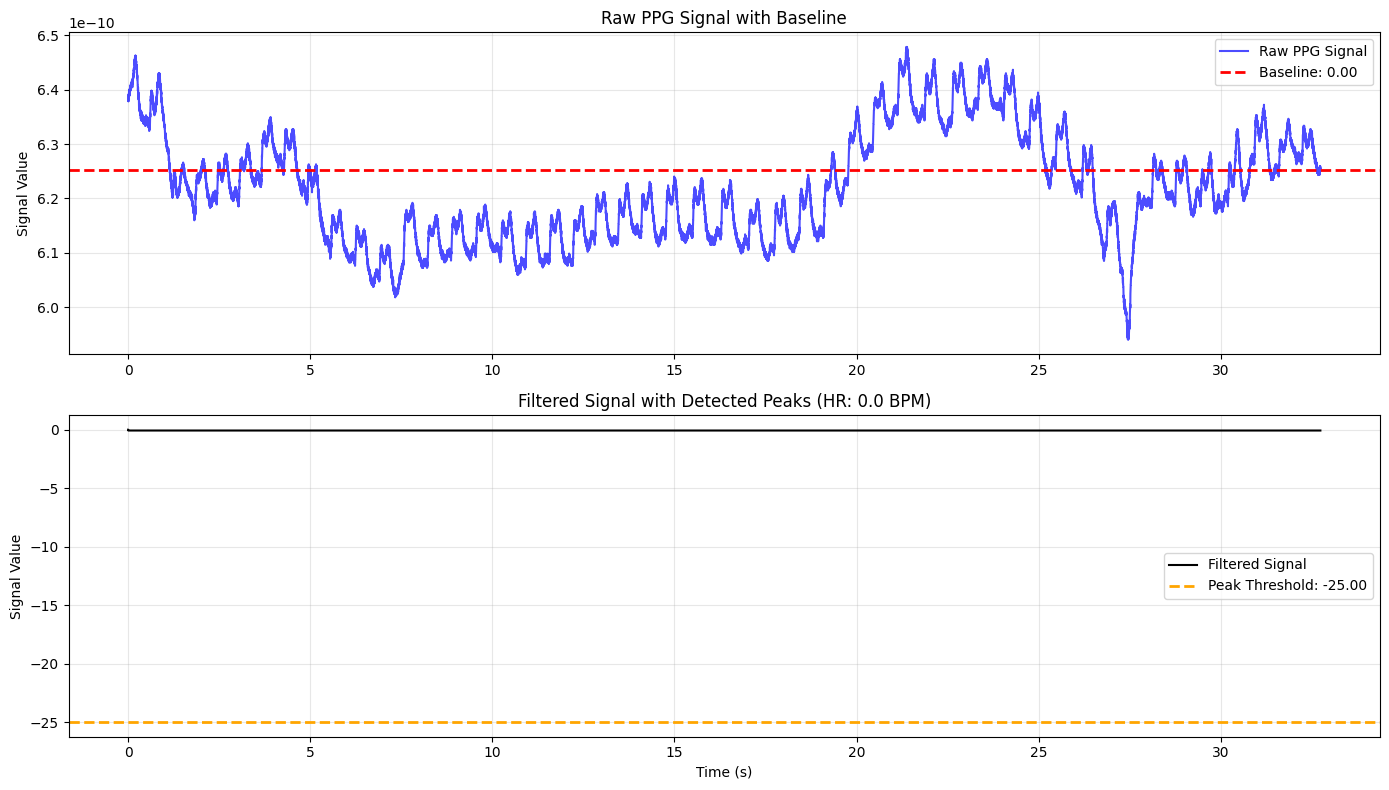


Collected 32736 samples


In [109]:
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic PPG signal (matching STM32 simul

# Initialize detector
detector = RealtimePulseDetector(
    sampling_rate=100,
    baseline_window=20,
    peak_spacing=100,
    peak_threshold_offset=25
)

# Process point-by-point (real-time simulation)
print("Processing data in real-time...")
for t, value in zip(time, current):
    detector.process_sample(value, t)

# Get results
print(f"\nFinal Heart Rate: {detector.get_heart_rate():.1f} BPM")
print(f"Total peaks detected: {len(detector.detected_peaks)}")

# Plot
detector.plot_results()

# Access raw data if needed
data = detector.get_signal_arrays()
print(f"\nCollected {len(data['time'])} samples")